In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

# Paths

In [2]:
MASTER = "/kaggle/input/datasets/ayastudentkhoumari/cleaned-dataset/algeria_trade_master_ml_ready.parquet"

print(os.path.exists(MASTER))

True


# Dataset Overview

In [3]:
pf = pq.ParquetFile(MASTER)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows       : {pf.metadata.num_rows:,}")
print(f"Columns    : {pf.metadata.num_columns}")
print(f"Row groups : {pf.num_row_groups}")

print("\nColumns:")

for i, col in enumerate(pf.schema.names, 1):
    print(f"{i:2}. {col}")

DATASET OVERVIEW
Rows       : 146,823,408
Columns    : 30
Row groups : 149

Columns:
 1. year
 2. product_code
 3. exporter
 4. partner
 5. fobvalue
 6. qty
 7. product_description
 8. gdp
 9. gdp_growth
10. population
11. trade_percent_gdp
12. inflation
13. dist
14. contig
15. comlang_off
16. colony
17. continent_j
18. landlocked_j
19. global_imports
20. world_imports
21. global_demand_index
22. hhi
23. algeria_exports
24. market_share
25. penetration_ratio
26. trade_balance
27. product_diversity
28. opportunity_score
29. opportunity_level
30. export_growth


# SMART SAMPLING

In [4]:
sample_parts = []

# sample only few row groups
sample_groups = [0, 20, 40, 60, 80, 100, 120, 140]

for rg in sample_groups:

    print(f"Reading row group {rg}...")

    chunk = pf.read_row_group(rg).to_pandas()

    sample_parts.append(
        chunk.sample(
            min(50000, len(chunk)),
            random_state=42
        )
    )

    del chunk
    gc.collect()

eda_df = pd.concat(sample_parts, ignore_index=True)

print("\nEDA sample shape:")
print(eda_df.shape)

Reading row group 0...
Reading row group 20...
Reading row group 40...
Reading row group 60...
Reading row group 80...
Reading row group 100...
Reading row group 120...
Reading row group 140...

EDA sample shape:
(363926, 30)


# Display Sample

In [5]:
display(eda_df.head())

print("\nData types:")
display(eda_df.dtypes)

,year,product_code,exporter,partner,fobvalue,qty,product_description,gdp,gdp_growth,population,trade_percent_gdp,inflation,dist,contig,comlang_off,colony,continent_j,landlocked_j,global_imports,world_imports,global_demand_index,hhi,algeria_exports,market_share,penetration_ratio,trade_balance,product_diversity,opportunity_score,opportunity_level,export_growth
0,2010,854110,BEL,AFG,0.758000,0.001000,"Electrical apparatus: diodes, other than photo...",1.585667e+10,14.362441,28284088.0,46.709896,2.178538,5416.121094,0,0,0,Asia,1,63.342999,9.662341e+06,0.008034,0.128268,5.063,0.001255,0.011967,0.758000,266,0.400512,Medium,0.0
1,2010,381300,BGR,GRC,29.730000,43.049999,Fire-extinguishers: preparations and charges a...,2.964177e+11,-5.693741,11121341.0,50.922520,4.712989,520.693726,1,0,0,Europe,0,1543.282959,2.235415e+05,0.000186,0.109673,0.000,0.002779,0.019264,29.730000,2703,0.400411,Medium,0.0
2,2010,620193,MMR,UKR,70.223999,3.872000,"Anoraks (including ski-jackets), wind-cheaters...",1.412092e+11,4.092004,46456004.0,95.729729,9.372931,6868.432129,0,0,0,Europe,0,25479.009766,5.099767e+06,0.004240,0.380516,3.957,0.017235,0.002756,70.223999,41,0.398427,Medium,0.0
3,2010,842481,BRA,COL,1235.130981,88.995003,"Mechanical appliances: for projecting, dispers...",2.864985e+11,4.494659,44777320.0,34.264603,2.272002,4399.133789,1,0,0,America,0,10040.863281,2.461720e+06,0.002047,0.126936,0.127,0.052479,0.123010,1235.130981,2308,0.372850,Low,0.0
4,2010,853120,BEL,RUS,895.229980,7.164000,"Signalling apparatus: electric, sound or visua...",1.524917e+12,4.500000,142849472.0,50.355507,6.849392,2261.250000,0,0,0,Asia,0,30242.621094,8.921601e+06,0.007418,0.123794,3.915,0.004794,0.029602,895.229980,2863,0.416853,High,0.0



Data types:


year                     int16
product_code            object
exporter                object
partner                 object
fobvalue               float32
qty                    float32
product_description     object
gdp                    float32
gdp_growth             float32
population             float32
trade_percent_gdp      float32
inflation              float32
dist                   float32
contig                    Int8
comlang_off               Int8
colony                    Int8
continent_j             object
landlocked_j              Int8
global_imports         float32
world_imports          float32
global_demand_index    float32
hhi                    float32
algeria_exports        float32
market_share           float32
penetration_ratio      float32
trade_balance          float32
product_diversity        int16
opportunity_score      float32
opportunity_level       object
export_growth          float32
dtype: object

# Missing Values

In [6]:
missing = (
    eda_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

print("Missing values:")
display(missing)

Missing values:


Series([], dtype: int64)

# Numerical Summary

In [7]:
display(
    eda_df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
year,363926.0,2016.923468,4.791044,2010.0,2012.0,2017.0,2022.0,2024.0
fobvalue,363926.0,1272.526978,30168.84375,0.001,0.832,7.907,76.760752,7813586.0
qty,363926.0,1177.171387,74995.476562,0.001,0.036,0.45925,7.951,27769394.0
gdp,363926.0,1181914103808.0,3343711207424.0,32105408.0,41950359552.0,238841135104.0,741999378432.0,28750955675648.0
gdp_growth,363926.0,2.239883,5.114693,-54.402092,0.787052,2.719244,4.56868,86.826752
population,363926.0,72617840.0,217506160.0,9646.0,5395790.0,13210998.0,51836240.0,1450935808.0
trade_percent_gdp,363926.0,93.228241,61.535336,1.995412,56.051529,75.941109,111.725029,430.568542
inflation,363926.0,5.282687,14.047918,-12.296984,1.381911,2.839664,5.411944,557.201843
dist,363926.0,5381.92041,4402.064453,59.617229,1600.171021,4753.380859,8289.029297,19812.039062
contig,363926.0,0.09323,0.290756,0.0,0.0,0.0,0.0,1.0


# Opportunity Level Distribution

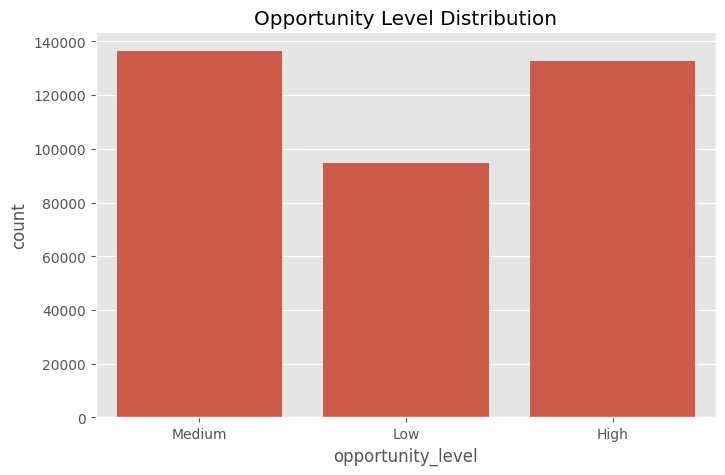

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x="opportunity_level"
)

plt.title("Opportunity Level Distribution")
plt.show()

# FOBVALUE Distribution

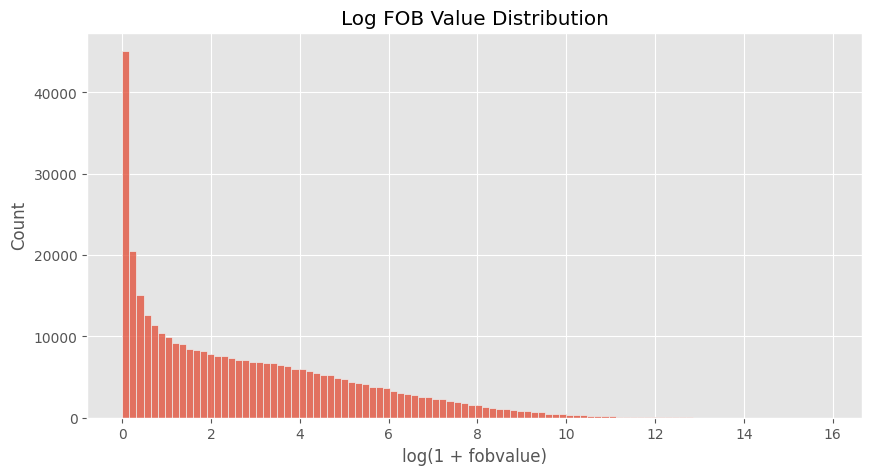

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(eda_df["fobvalue"]),
    bins=100
)

plt.title("Log FOB Value Distribution")
plt.xlabel("log(1 + fobvalue)")
plt.show()

# Top Exporters

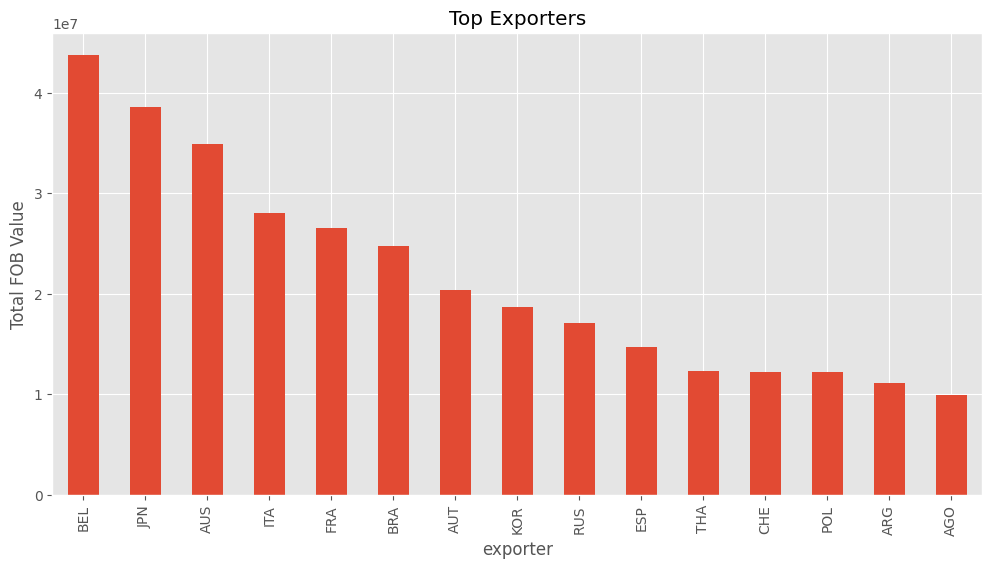

In [10]:
top_exporters = (
    eda_df.groupby("exporter")["fobvalue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

top_exporters.plot(kind="bar")

plt.title("Top Exporters")
plt.ylabel("Total FOB Value")

plt.show()

# Top Importers

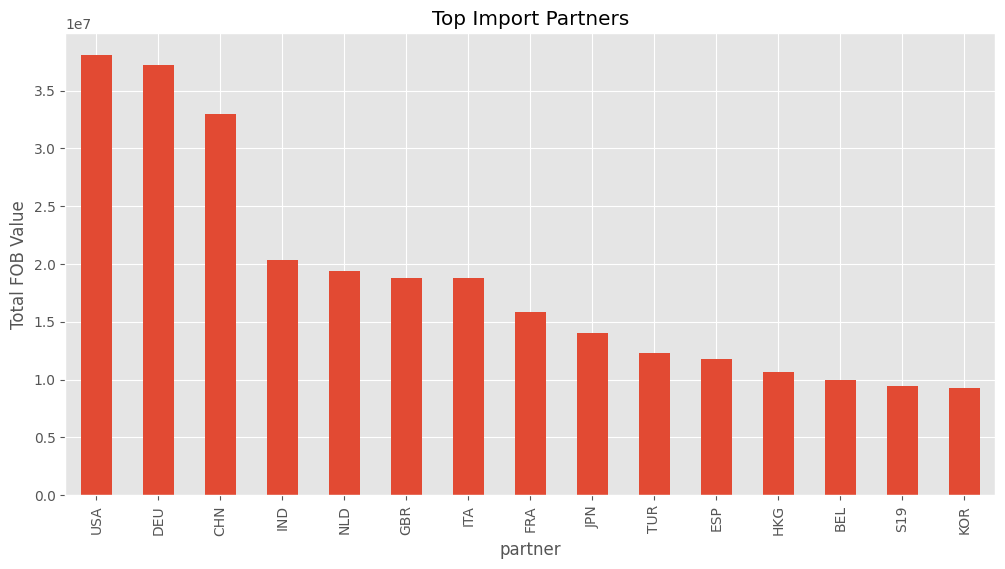

In [11]:
top_partners = (
    eda_df.groupby("partner")["fobvalue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

top_partners.plot(kind="bar")

plt.title("Top Import Partners")
plt.ylabel("Total FOB Value")

plt.show()

# Top Products

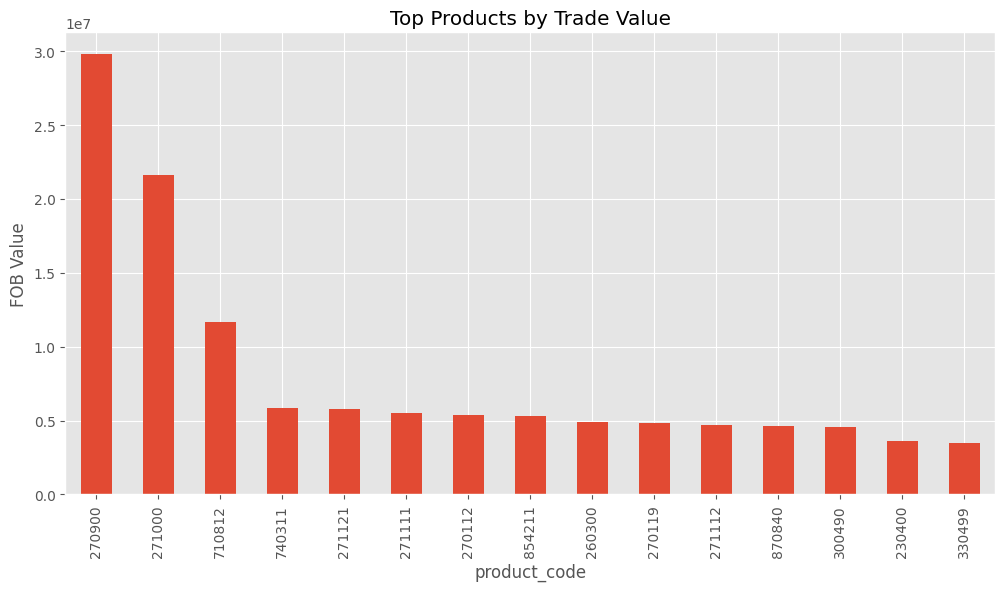

In [12]:
top_products = (
    eda_df.groupby("product_code")["fobvalue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top Products by Trade Value")
plt.ylabel("FOB Value")

plt.show()

# GDP vs FOBVALUE

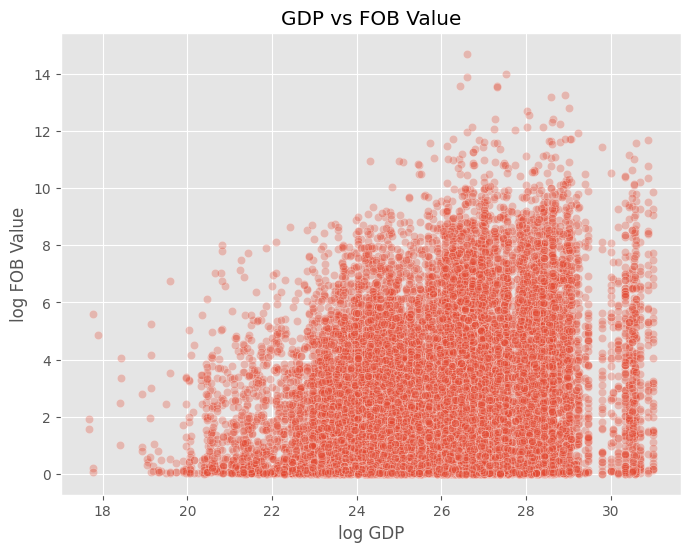

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=eda_df.sample(20000, random_state=42),
    x=np.log1p(eda_df.sample(20000, random_state=42)["gdp"]),
    y=np.log1p(eda_df.sample(20000, random_state=42)["fobvalue"]),
    alpha=0.3
)

plt.title("GDP vs FOB Value")
plt.xlabel("log GDP")
plt.ylabel("log FOB Value")

plt.show()

# Correlation Matrix

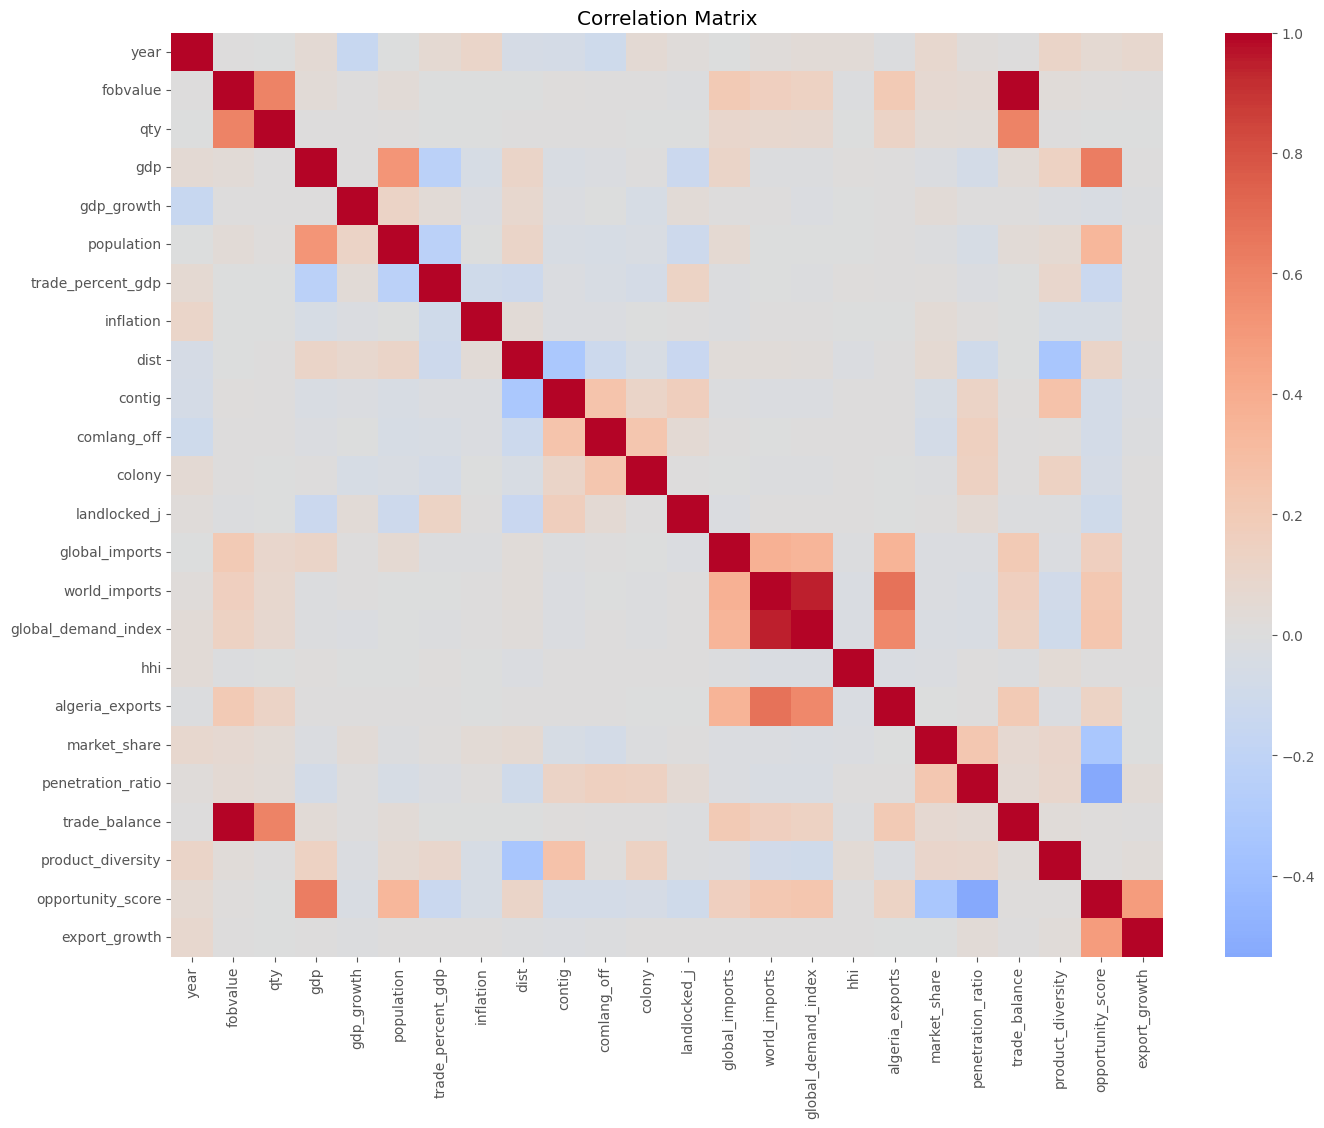

In [14]:
numeric_df = eda_df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Market Share Distribution

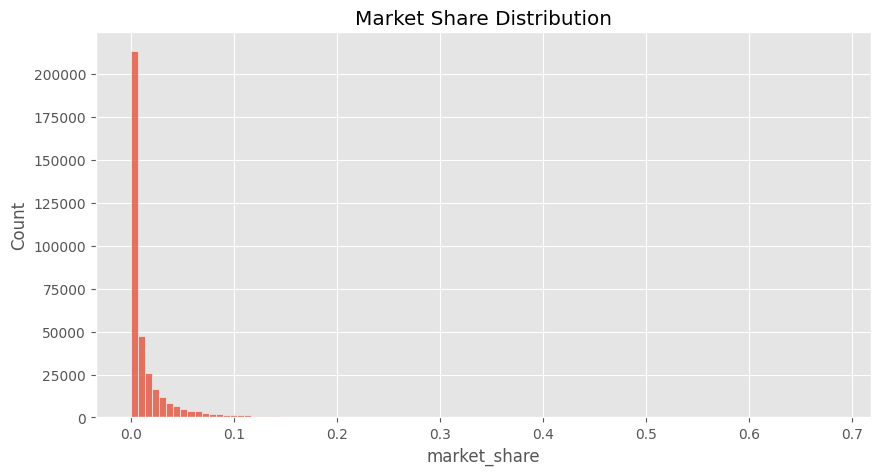

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(eda_df["market_share"]),
    bins=100
)

plt.title("Market Share Distribution")

plt.show()

# Global Demand vs Opportunity

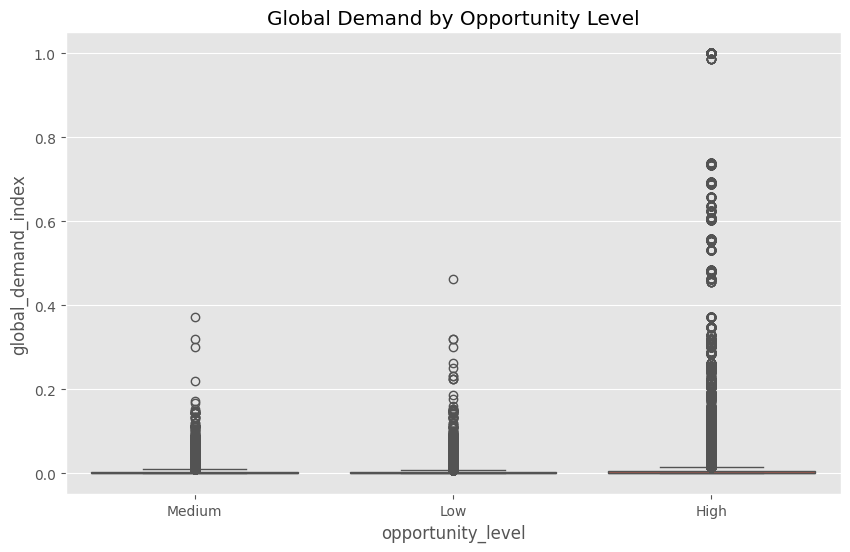

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=eda_df,
    x="opportunity_level",
    y="global_demand_index"
)

plt.title("Global Demand by Opportunity Level")

plt.show()

# Product Diversity Analysis

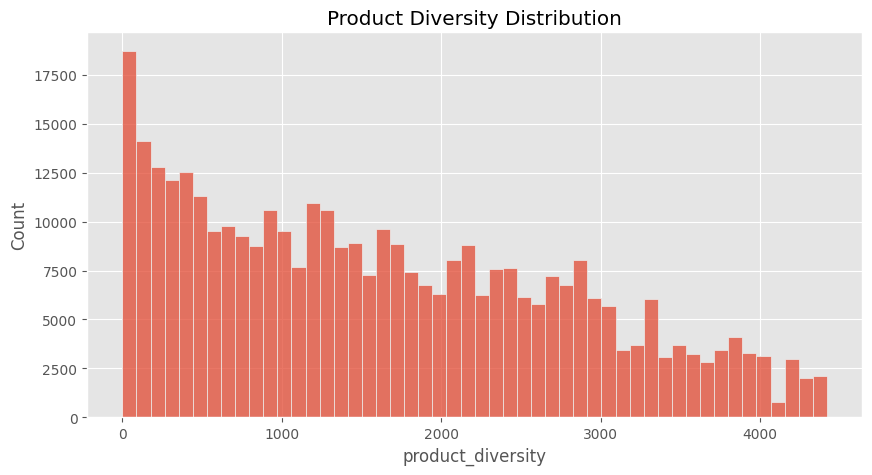

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    eda_df["product_diversity"],
    bins=50
)

plt.title("Product Diversity Distribution")

plt.show()

# Yearly Trade Evolution

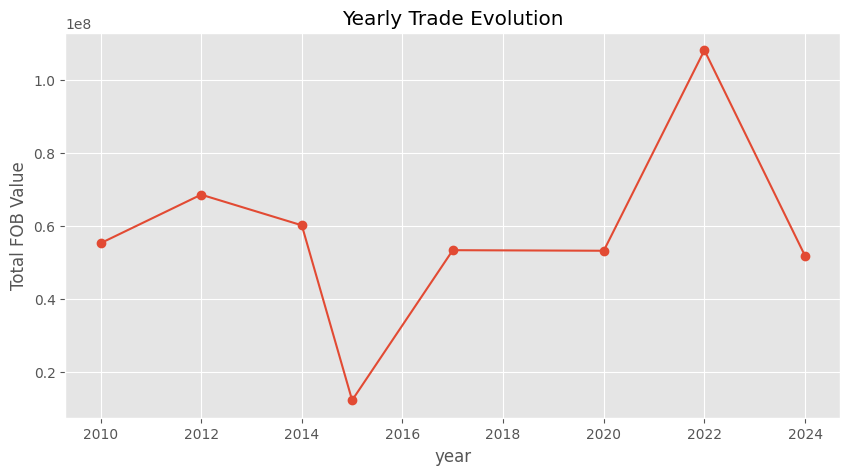

In [18]:
yearly_trade = (
    eda_df.groupby("year")["fobvalue"]
    .sum()
)

plt.figure(figsize=(10,5))

yearly_trade.plot(marker="o")

plt.title("Yearly Trade Evolution")
plt.ylabel("Total FOB Value")

plt.show()

# Final EDA Insights

In [19]:
print("""
EDA COMPLETE

Key analyses performed:
- Dataset structure
- Missing values
- Target balance
- Trade distributions
- Country analysis
- Product analysis
- Correlation analysis
- Economic relationships
- Opportunity analysis

Dataset is ready for:
- Clustering
- Classification
- Forecasting
- Recommendation systems
- Trade opportunity modeling
""")


EDA COMPLETE

Key analyses performed:
- Dataset structure
- Missing values
- Target balance
- Trade distributions
- Country analysis
- Product analysis
- Correlation analysis
- Economic relationships
- Opportunity analysis

Dataset is ready for:
- Clustering
- Classification
- Forecasting
- Recommendation systems
- Trade opportunity modeling

